In [3]:
import numpy as np
from matplotlib import pyplot as plt

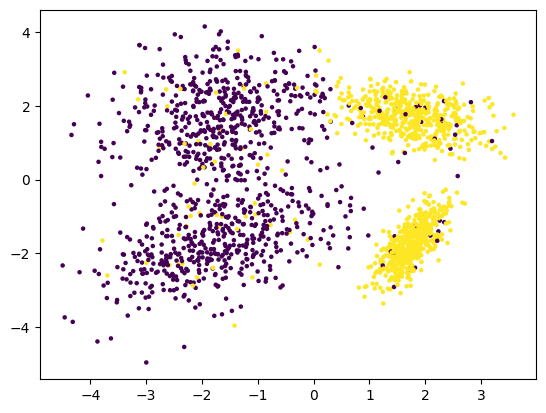

In [16]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=2000, n_features=2, n_redundant=0, flip_y=0.1, random_state=21, class_sep=1.75)
plt.scatter(X[:,0], X[:,1], c=y, s=5)

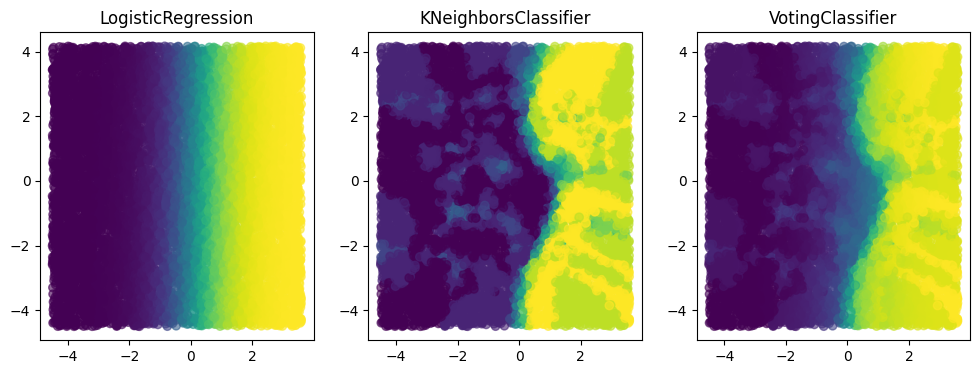

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

clf1 = LogisticRegression().fit(X,y)
clf2 = KNeighborsClassifier(n_neighbors=10).fit(X,y)
eclf = VotingClassifier(estimators=[('lr', clf1), ('knn', clf2)], voting='soft', weights=[.5,.5]).fit(X,y)

X_test = np.concatenate([
        np.random.uniform(X[:, 0].min(), X[:, 0].max(), (10000, 1)), 
        np.random.uniform(X[:, 0].min(), X[:, 1].max(), (10000, 1))
    ], axis=1)

fig, axes = plt.subplots(1,3, figsize=(12,4))
for axes, mod in zip(axes, [clf1, clf2, eclf]):
    y_proba = mod.predict_proba(X_test)
    axes.set_title(mod.__class__.__name__)
    axes.scatter(X_test[:, 0], X_test[:, 1], c=y_proba[:, 1], alpha=0.6)

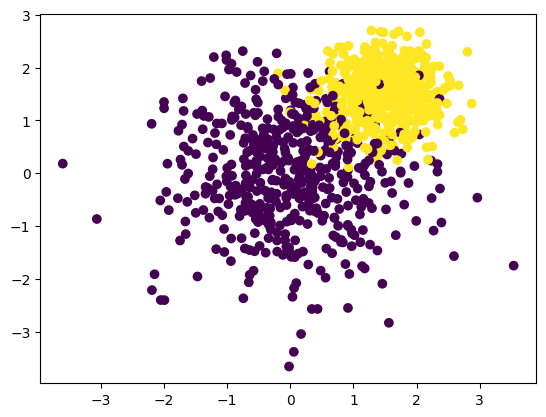

In [42]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=1000, centers=[(0,0),(1.5,1.5)], cluster_std=[1,0.5])
plt.scatter(X[:,0], X[:,1], c=y)

In [44]:
!pip install scikit-lego


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-lego]
   -------------------- ------------------- 1/2 [scikit-l

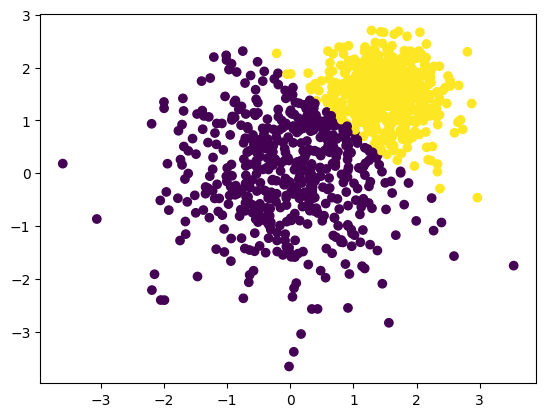

In [51]:
from sklego.meta import Thresholder

ift = Thresholder(LogisticRegression(), threshold=0.5).fit(X, y)
y_pred = ift.predict(X)
plt.scatter(X[:,0], X[:,1], c=y_pred)

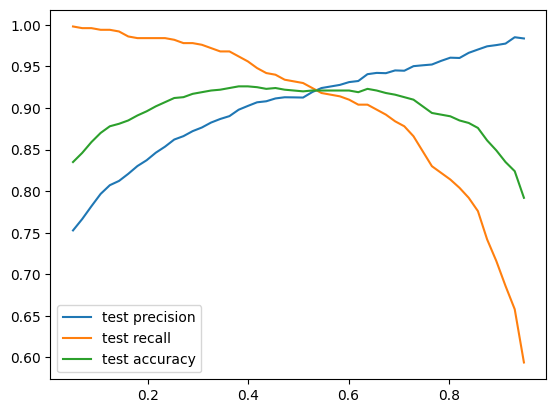

In [53]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([('model', Thresholder(LogisticRegression(solver='lbfgs'), threshold=0.1))])

model = GridSearchCV( estimator=pipe,
                      param_grid={'model__threshold': np.linspace(.05,.95,50)},
                      cv=5,
                      scoring={"precision":make_scorer(precision_score), "recall":make_scorer(recall_score), "accuracy": make_scorer(accuracy_score)},
                      refit="precision",
                      return_train_score=True,
                      n_jobs=-1
                      )

model.fit(X, y)
plt.plot(model.cv_results_['param_model__threshold'], model.cv_results_['mean_test_precision'], label="test precision")
plt.plot(model.cv_results_['param_model__threshold'], model.cv_results_['mean_test_recall'], label="test recall")
plt.plot(model.cv_results_['param_model__threshold'], model.cv_results_['mean_test_accuracy'], label="test accuracy")
plt.legend()

In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import FeatureUnion, Pipeline
from sklego.preprocessing import ColumnSelector
from sklearn.preprocessing import OneHotEncoder

feature_pipe = Pipeline([
    ("datagrab", FeatureUnion([
        ('descrete', Pipeline([
            ('grab', ColumnSelector([0,1])),
            ('encode', OneHotEncoder(categories="auto", sparse_output=False))
        ])),
        ('continous', Pipeline([
            ('grab', ColumnSelector("time")),
            ('standardize', StandardScaler())
        ]))
    ]))
])

pipe = Pipeline([
    ('features', feature_pipe),
    ('model', LogisticRegression())
])

In [98]:
import pandas as pd

X = np.concatenate([
        np.random.randint(1, 5, (1000, 1)),
        np.random.uniform(0, 5, (1000, 1)),
    ], axis=1)
X = pd.DataFrame(X, columns=["diet", "time"])
y = X["time"].values * X["diet"].values + X["diet"].values 

def plot_grouped_results(X, y):
    diets = X["diet"].unique()
    plt.figure(figsize=(8,6))

    for diet in sorted(diets):
        mask = X["diet"] == diet
        time_vals = X.loc[mask, "time"]

        plt.plot(time_vals, y[mask], label=f"Diet {diet}")  # scatter


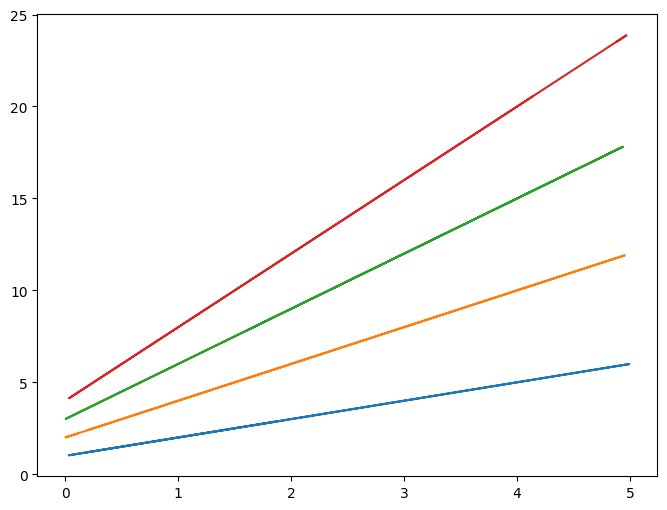

In [99]:
plot_grouped_results(X, y)

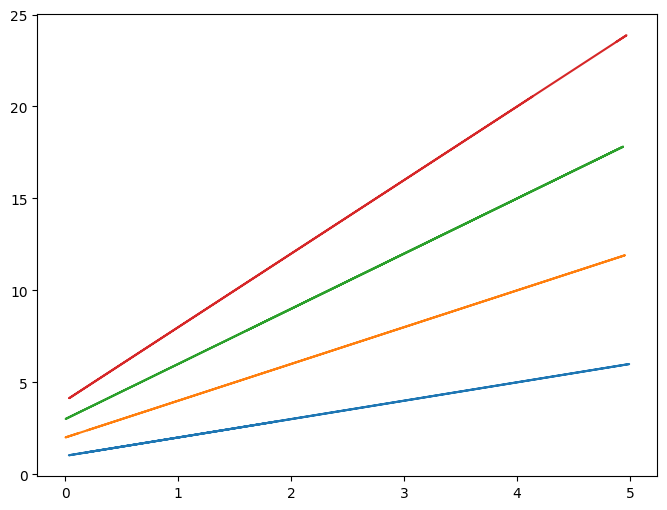

In [100]:
from sklearn.linear_model import LinearRegression
from sklego.meta import GroupedPredictor
gc = GroupedPredictor(LinearRegression(), groups=["diet"]).fit(X, y)
y_pred= gc.predict(X)
plot_grouped_results(X, y_pred)

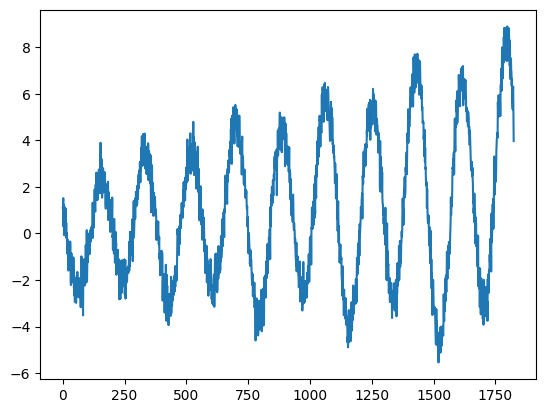

In [102]:
from sklego.datasets import make_simpleseries
from sklego.meta import GroupedPredictor, DecayEstimator

yt = make_simpleseries(seed=21)
plt.plot(yt)